In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('flipkart_sales.csv')
df.head()

,Order ID,Product Name,Category,Price (INR),Quantity Sold,Total Sales (INR),Order Date,Payment Method,Customer Rating
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1


In [3]:
df.shape

(1000, 9)

In [4]:
df.isnull().sum()

,0
Order ID,0
Product Name,0
Category,0
Price (INR),0
Quantity Sold,0
Total Sales (INR),0
Order Date,0
Payment Method,0
Customer Rating,0


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Order ID           1000 non-null   object 
 1   Product Name       1000 non-null   object 
 2   Category           1000 non-null   object 
 3   Price (INR)        1000 non-null   float64
 4   Quantity Sold      1000 non-null   int64  
 5   Total Sales (INR)  1000 non-null   float64
 6   Order Date         1000 non-null   object 
 7   Payment Method     1000 non-null   object 
 8   Customer Rating    1000 non-null   float64
dtypes: float64(3), int64(1), object(5)
memory usage: 70.4+ KB


In [7]:
df.describe()

,Price (INR),Quantity Sold,Total Sales (INR),Customer Rating
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,24520.258260,3.097000,75213.112740,3.011100
std,14187.611227,1.410525,59457.598352,1.145408
min,139.850000,1.000000,419.550000,1.000000
25%,12378.905000,2.000000,28581.765000,2.000000
50%,24650.015000,3.000000,57358.300000,3.100000
75%,35981.925000,4.000000,110618.595000,4.000000
max,49911.750000,5.000000,243903.900000,5.000000


array([[<Axes: title={'center': 'Price (INR)'}>,
        <Axes: title={'center': 'Quantity Sold'}>],
       [<Axes: title={'center': 'Total Sales (INR)'}>,
        <Axes: title={'center': 'Customer Rating'}>]], dtype=object)

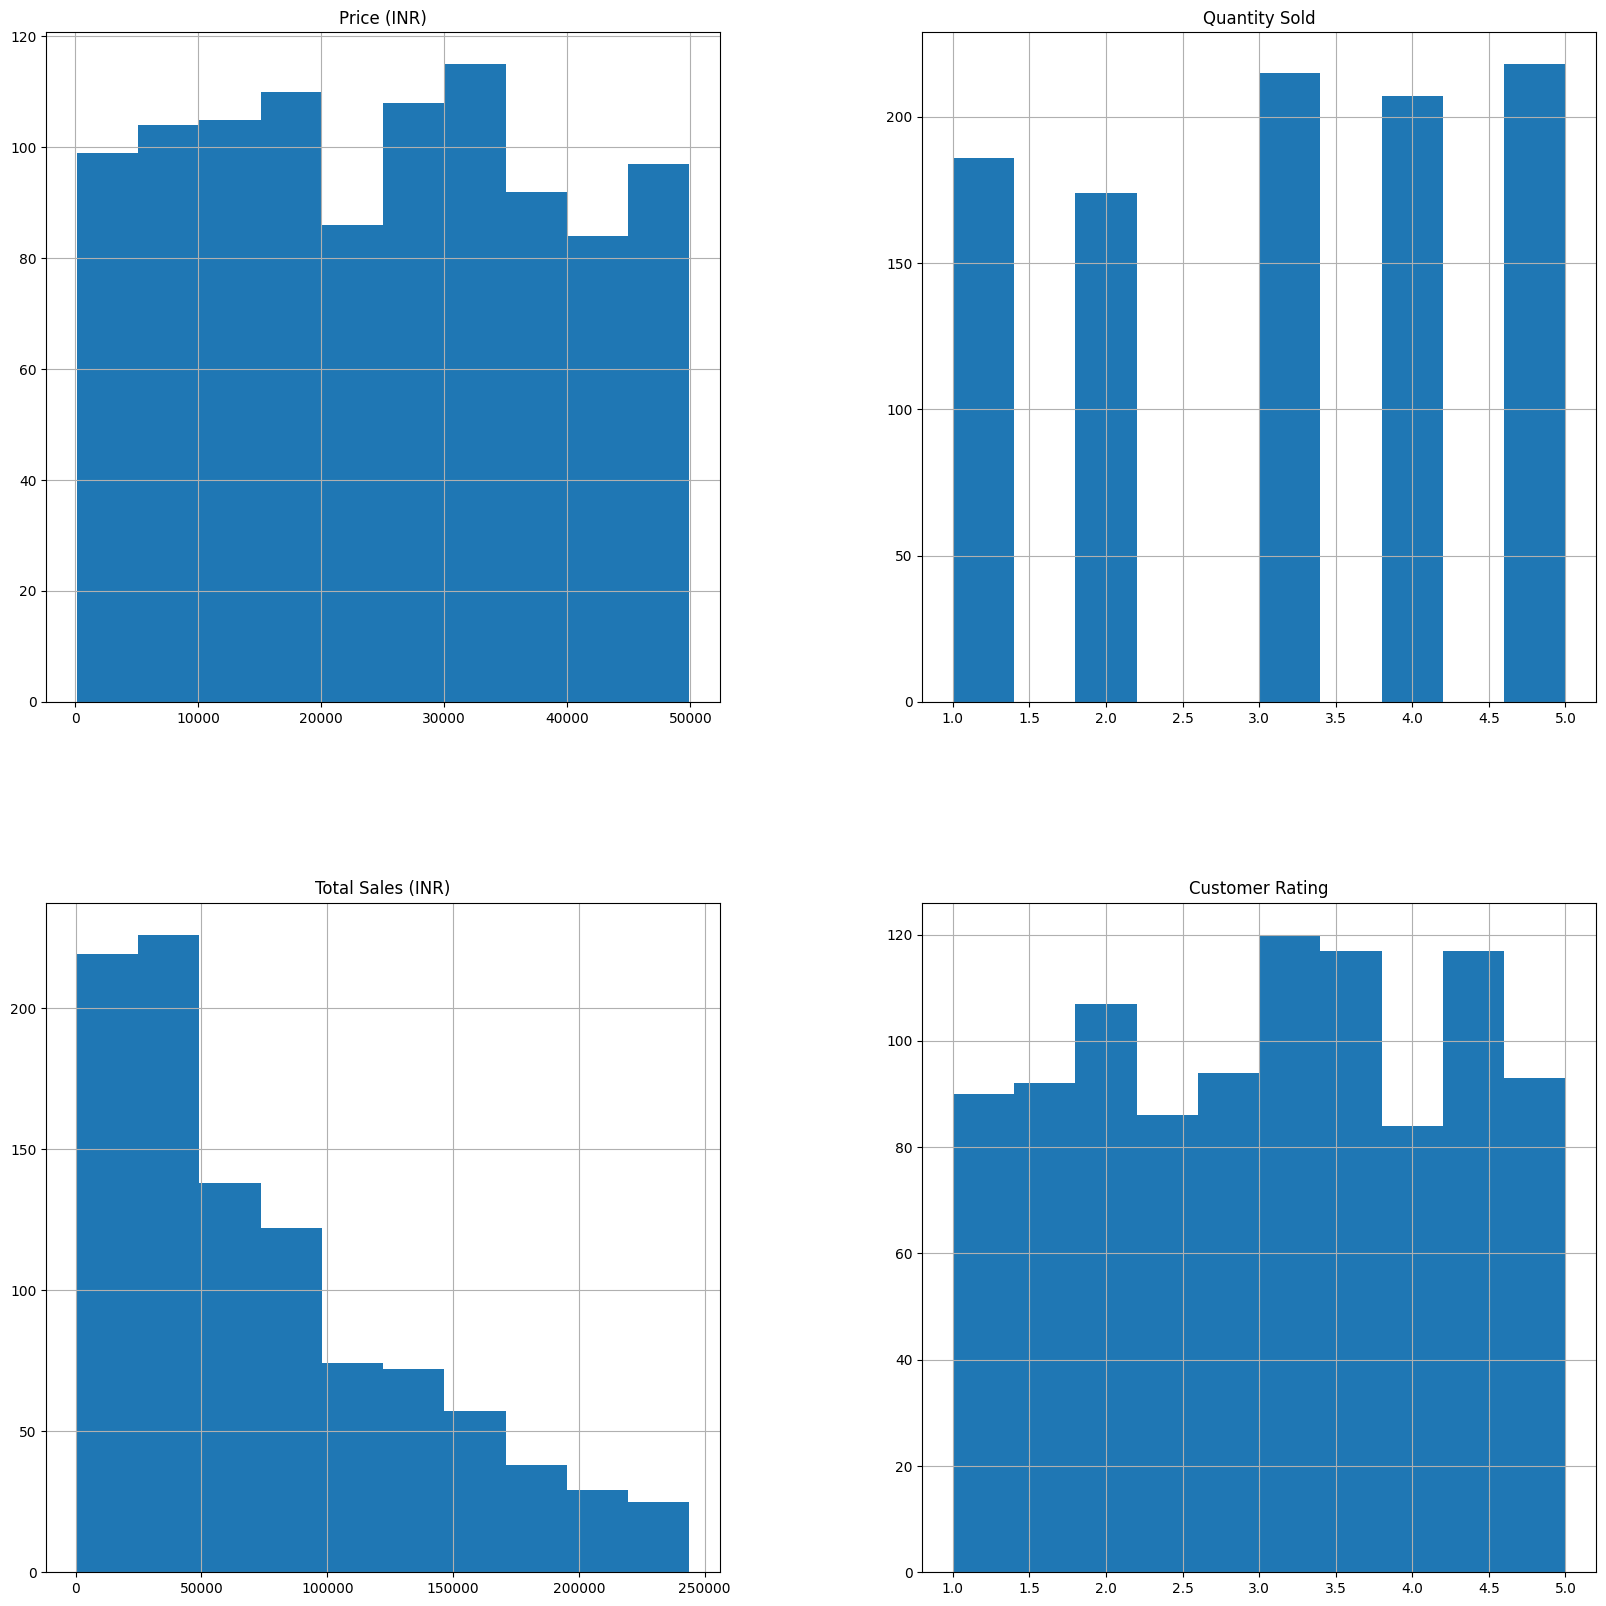

In [8]:
df.hist(figsize=(20,20))

In [9]:
df['Category'].value_counts()

,count
Category,
Electronics,217
Books,209
Home & Kitchen,193
Beauty,192
Clothing,189


<Axes: xlabel='count', ylabel='Category'>

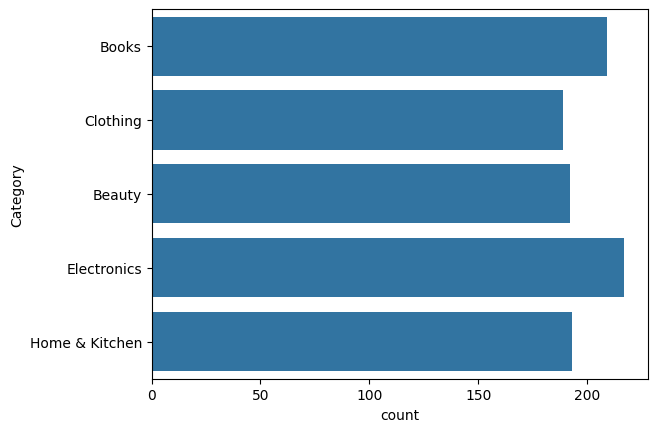

In [10]:
sns.countplot(y='Category',data=df)

<Axes: xlabel='Price (INR)', ylabel='Total Sales (INR)'>

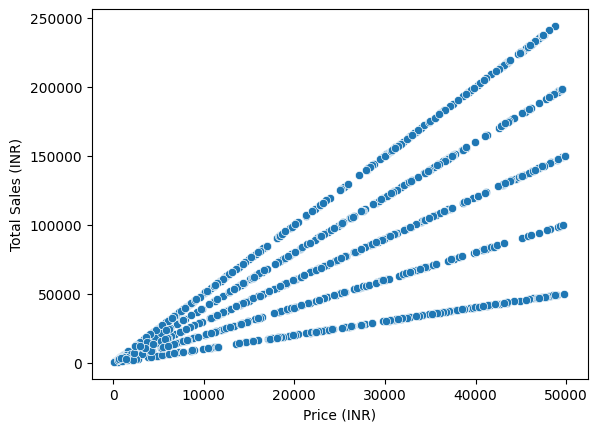

In [11]:
sns.scatterplot(x='Price (INR)',y='Total Sales (INR)',data=df)

<Axes: xlabel='Customer Rating', ylabel='Total Sales (INR)'>

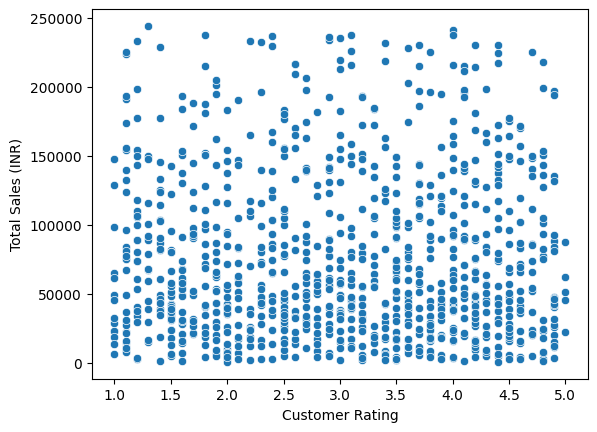

In [12]:
sns.scatterplot(x='Customer Rating', y='Total Sales (INR)', data=df)

<Axes: xlabel='Category', ylabel='Total Sales (INR)'>

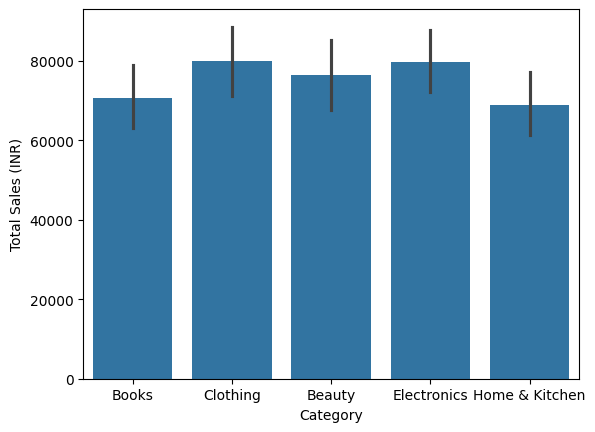

In [13]:
sns.barplot(x='Category', y='Total Sales (INR)', data=df)

<Axes: >

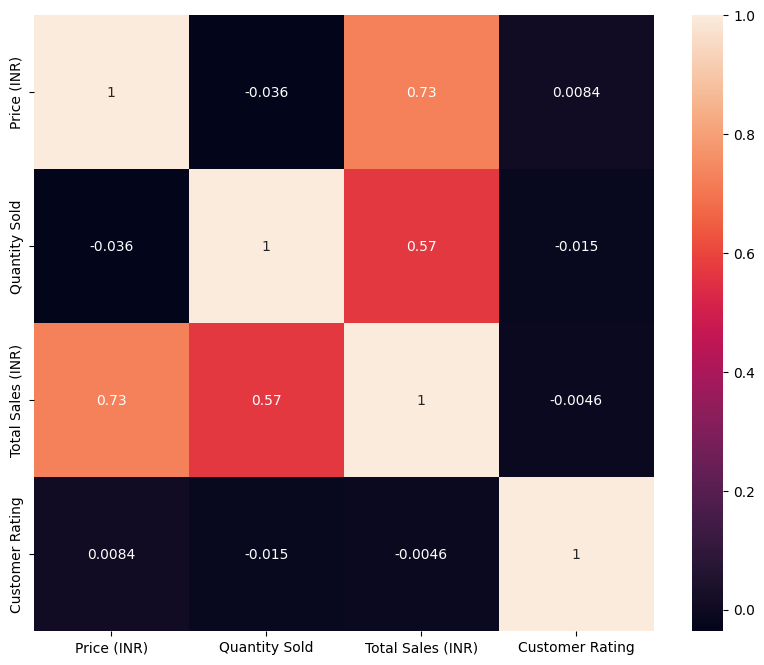

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True)

<Axes: ylabel='Price (INR)'>

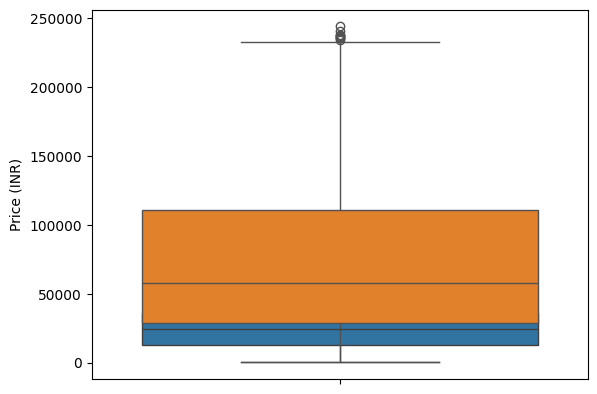

In [15]:
sns.boxplot(df['Price (INR)'])
sns.boxplot(df['Total Sales (INR)'])

In [16]:
df.columns

Index(['Order ID', 'Product Name', 'Category', 'Price (INR)', 'Quantity Sold',
       'Total Sales (INR)', 'Order Date', 'Payment Method', 'Customer Rating'],
      dtype='object')

In [17]:
df.rename(columns={'Total Sales (INR)':'Sales','Price (INR)':'Price'},inplace=True)

In [18]:
df['Order Date']=pd.to_datetime(df['Order Date'])

In [19]:
df['Month']=df['Order Date'].dt.month_name()

In [20]:
df.head()

,Order ID,Product Name,Category,Price,Quantity Sold,Sales,Order Date,Payment Method,Customer Rating,Month
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5,September
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9,December
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4,May
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2,November
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1,December


In [21]:
df['Quarter']=df['Order Date'].dt.quarter

In [22]:
df['Is_weekend']=(df['Order Date'].dt.dayofweek>=5).astype(int)

In [23]:
df.head()

,Order ID,Product Name,Category,Price,Quantity Sold,Sales,Order Date,Payment Method,Customer Rating,Month,Quarter,Is_weekend
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5,September,3,0
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9,December,4,0
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4,May,2,1
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2,November,4,0
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1,December,4,0


In [24]:
df['price_bucket']=pd.cut(df['Price'],bins=[0,5000,15000,30000,50000],labels=['Low','Medium','High','Premium'])

In [25]:
df.head()

,Order ID,Product Name,Category,Price,Quantity Sold,Sales,Order Date,Payment Method,Customer Rating,Month,Quarter,Is_weekend,price_bucket
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5,September,3,0,Premium
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9,December,4,0,Medium
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4,May,2,1,Medium
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2,November,4,0,Premium
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1,December,4,0,High


In [26]:
df['Rating_category']=pd.cut(df['Customer Rating'],bins=[0,3,4,5],labels=['Low','Medium','High'])

In [27]:
df.head()

,Order ID,Product Name,Category,Price,Quantity Sold,Sales,Order Date,Payment Method,Customer Rating,Month,Quarter,Is_weekend,price_bucket,Rating_category
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5,September,3,0,Premium,Medium
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9,December,4,0,Medium,Medium
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4,May,2,1,Medium,High
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2,November,4,0,Premium,Medium
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1,December,4,0,High,Medium


In [28]:
X=df.drop(columns=['Order ID','Sales','Order Date'])
y=df['Sales']

In [29]:
X = pd.get_dummies(X, drop_first=True)

In [30]:
df.head()

,Order ID,Product Name,Category,Price,Quantity Sold,Sales,Order Date,Payment Method,Customer Rating,Month,Quarter,Is_weekend,price_bucket,Rating_category
0,ORD00001,Educational Book,Books,49069.56,2,98139.12,2024-09-12,Debit Card,3.5,September,3,0,Premium,Medium
1,ORD00002,Jeans,Clothing,12755.85,4,51023.40,2024-12-18,UPI,3.9,December,4,0,Medium,Medium
2,ORD00003,Face Cream,Beauty,11092.19,4,44368.76,2024-05-18,Debit Card,4.4,May,2,1,Medium,High
3,ORD00004,Smartwatch,Electronics,32657.81,1,32657.81,2024-11-08,Debit Card,3.2,November,4,0,Premium,Medium
4,ORD00005,Cookware Set,Home & Kitchen,26590.08,3,79770.24,2024-12-27,UPI,3.1,December,4,0,High,Medium


In [31]:
X

,Price,Quantity Sold,Customer Rating,Quarter,Is_weekend,Product Name_Comic Book,Product Name_Cookbook,Product Name_Cookware Set,Product Name_Dress,Product Name_Educational Book,...,Month_March,Month_May,Month_November,Month_October,Month_September,price_bucket_Medium,price_bucket_High,price_bucket_Premium,Rating_category_Medium,Rating_category_High
0,49069.56,2,3.5,3,0,False,False,False,False,True,...,False,False,False,False,True,False,False,True,True,False
1,12755.85,4,3.9,4,0,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
2,11092.19,4,4.4,2,1,False,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
3,32657.81,1,3.2,4,0,False,False,False,False,False,...,False,False,True,False,False,False,False,True,True,False
4,26590.08,3,3.1,4,0,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,28995.81,3,5.0,1,0,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
996,32799.51,2,2.4,4,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
997,40840.80,1,3.1,3,0,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
998,34741.79,4,3.2,4,0,False,False,True,False,False,...,False,False,False,True,False,False,False,True,True,False


In [32]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [34]:
y_pred=model.predict(X_test)

In [35]:
from sklearn.metrics import mean_squared_error, r2_score

print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('R-squared:', r2_score(y_test, y_pred))

Mean Squared Error: 400703845.5447705
R-squared: 0.8913116947464974


In [36]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [37]:
print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R² Score :", r2_score(y_test, rf_pred))

RMSE : 977.2959034000852
R² Score : 0.9997409333774625


In [38]:
df.to_csv("flipkart_sales_cleaned.csv", index=False)

In [39]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.to_csv("feature_importance.csv", index=False)

In [40]:
results = pd.DataFrame({
    "Actual Sales": y_test,
    "Predicted Sales": rf_pred
})

results.to_csv("prediction_results.csv", index=False)